# MLP Neural Networks
In this notebook we will build several different multi-layer perceptron models. Each time, we will add some common functionality to the model. We will start with building an easy to analyze system and build the overall complexity each time.  

## Getting some data to test with:
Let's start by grabbing some data for a (small) hand written digits dataset. 

In [1]:
# lets load up the handwritten digit dataset
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

ds = load_digits()
X = ds.data/16.0-0.5 # normalize the input, very important
y = ds.target
y_ohe = encoder.fit_transform(y.reshape(-1, 1))

print(X.shape)
print(y.shape)
print(np.min(X),np.max(X))
print(np.unique(y))

(1797, 64)
(1797,)
-0.5 0.5
[0 1 2 3 4 5 6 7 8 9]


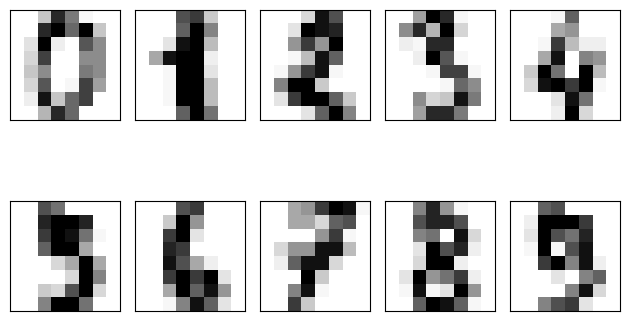

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True,)
ax = ax.flatten()
for i in range(10):
    img = X[y == i][0].reshape(8, 8)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

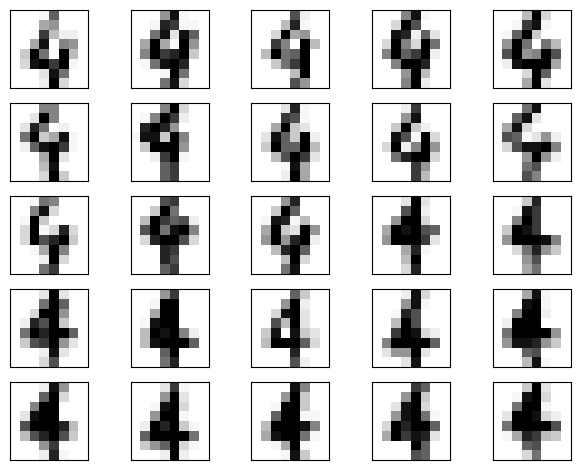

In [3]:
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True,)
ax = ax.flatten()
digit = 4
x_digits = X[y == digit]
for i in range(25):
    img = x_digits[i].reshape(8, 8)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_ohe, y_test_ohe, y_train, y_test = train_test_split(
    X,y_ohe,y,test_size = 0.2)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1437, 64)
(1437,)
(360, 64)
(360,)


_____
# Neural Networks Compared to Logistic Regression
The single layer network can be summarized with the notation given by previously covered topics (linear and logistic regression). When we calculated objective functions for linear regression and logistic regression we used the maximum likelihood priciple, showing that (under Gaussian noise) this led to minimizing the squared error of the output.

This is identical to the objective function for generic, single layer neural networks, where $\mathbf{y}^{(i)}$ is a one-hot-encoded representation of the class for the $i^{th}$ instance. We can also replace $\hat{\mathbf{y}}$ with the neural network activation $\phi(\mathbf{W}\cdot \mathbf{x})$:
$$ J(\mathbf{W}) \quad  = \sum_i^M (\mathbf{y}^{(i)}-\hat{\mathbf{y}}^{(i)})^2 \quad = \sum_i^M (\mathbf{y}^{(i)}-\phi(\mathbf{W}\cdot \mathbf{x}^{(i)}))^2$$

To solve, we need the gradient, $\nabla J(\mathbf{W})$. And then we can use the Widrow-Hoff learning Rule: $ \mathbf{W}\leftarrow\mathbf{W} +\eta\nabla J(\mathbf{W})$. This is identical to one-versus-all logistic regression optimization because we can treat each row of $\mathbf{W}$ independently (separate optimizations):
$$ \mathbf{w}\leftarrow\mathbf{w} +\eta[ \mathbf{X}*(\mathbf{y}-\mathbf{\hat{y}})] $$
$$ \mathbf{w}_{row}\leftarrow\mathbf{w}_{row} +\eta[ \mathbf{X}*(\mathbf{y}_{row}-\mathbf{\hat{y}}_{row})] $$

The same is true for the update equation of the perceptron with a sigmoid activation function:
$$ \mathbf{w}\leftarrow\mathbf{w} +\eta[ \mathbf{X}*(\mathbf{y}-\mathbf{g(x)})] $$

$$ \mathbf{w}_{row}\leftarrow\mathbf{w}_{row} +\eta[ \mathbf{X}*(\mathbf{y}_{row}-\mathbf{g(x)}_{row})] $$

This means that the update equations are identical to the case of linear and logistic regression, using one-versus-all! So all of this we have already looked at and solved! But, what about when we add more layers?


# Multi-layer Neural Networks
In the multilayer perceptron, we need to adjust some notation:

<img src="https://raw.githubusercontent.com/eclarson/MachineLearningNotebooks/master/PDF_Slides/MultiLayerNetwork.png" width="500">


## Formulation of multi-layer perceptron
Our objective function can stay the same, using mean squared error. However, the MSE is between two vectors when there are $C$ total classes in the classification problem:
$$ J(\mathbf{W}) = \sum_k^M (\mathbf{y}^{(k)}-\left[\mathbf{a}^{(L)}\right]^{(k)})^2 = 
                   \sum_k^M \left(\begin{bmatrix}y_0\\ y_1\\ \vdots \\ y_C \end{bmatrix}^{(k)}-\begin{bmatrix}a_0^{(L)}\\ a_1^{(L)}\\ \vdots \\ a_C^{(L)} \end{bmatrix}^{(k)} \right)^2  $$

Where $\mathbf{a}^{(L)}$ is a function of every $w_{i,j}^{(l)}$ and $b_{i}^{(l)}$ element in the various layers. The derivative of this objective function with respect to the final layer becomes:
$$  \frac{\partial J(\mathbf{W})}{\partial [\mathbf{z}^{(L-1)}]^{(k)}}  = -2\left(\mathbf{y}^{(k)}-{[\mathbf{a}^{(L)}]^{(k)}}\right) $$

And the update equation becomes:
$$  w_{i,j}^{(l)} \leftarrow w_{i,j}^{(l)} - \eta \frac{\partial J(\mathbf{W})}{\partial w_{i,j}^{(l)}}
\quad \quad \mathbf{W}^{(l)} \leftarrow \mathbf{W}^{(l)} - \eta \frac{\partial J(\mathbf{W})}{\partial \mathbf{W}^{(l)}}
$$

However, this is not tractable to compute by hand for each network architecture, so we expand the gradient calculation using the chain rule to get partial derivatives (see lecture notes):
$$  \frac{\partial J(\mathbf{W})}{\partial w_{i,j}^{(l)}} = 
\left[\frac{\partial \mathbf{z}^{(l+1)} }{\partial\mathbf{z}^{(l)}}\right]^T 
\frac{\partial\mathbf{z}^{(l)}}{\partial w_{i,j}^{(l)}}
\frac{\partial J(\mathbf{W})}{\partial\mathbf{z}^{(l+1)}}  
 $$

Here each element in the equation is the derivative applied as chain rule, such that many multiplications of derivatives results. Here is an expanded view of the operations:
$$  \frac{\partial J(\mathbf{W})}{\partial w_{i,j}^{(l)}} = 
\underbrace{\left[\frac{\partial \mathbf{z}^{(l+1)} }{\partial\mathbf{z}^{(l)}}\right]^T   
\frac{\partial\mathbf{z}^{(l)}}{\partial w_{i,j}^{(l)}}}_{\text{Derivative Current Layer, Chain Rule}}
\underbrace{\frac{\partial J(\mathbf{W})}{\partial\mathbf{z}^{(l+1)}}}_{\text{Sensitivity from next Layer}} $$

After some computation, we can derive that: 
$$ \frac{\partial J(\mathbf{W})}{\partial\mathbf{z}^{(l)}} = \underbrace{\mathbf{a}^{(l+1)}*(1-\mathbf{a}^{(l+1)})}_{\partial\sigma} \cdot \underbrace{\mathbf{W}^{(l+1)}}_{\partial z / \partial W} \frac{\partial J(\mathbf{W})}{\partial\mathbf{z}^{(l+1)}} $$

This sets up a recurrence relation such that if we know $\frac{\partial J(\mathbf{W})}{\partial\mathbf{z}^{(l)}}$ for the final layer, we can use it to get the derivatives for the previous layers. For a two layer network, the final layer gradient can be formulated as:
$$  \frac{\partial J(\mathbf{W})}{\partial\mathbf{z}^{(2)}} = \frac{\partial}{\partial\mathbf{z}^{(2)}} (\mathbf{y}^{(k)}-\phi(\mathbf{z}^{(2)}))^2 $$

$$  \frac{\partial J(\mathbf{W})}{\partial\mathbf{z}^{(2)}}  = -2(\mathbf{y}^{(k)}-\mathbf{a}^{(3)})*\mathbf{a}^{(3)}*(1-\mathbf{a}^{(3)}) $$

where $\mathbf{y}^{(k)}$ is the $k^{th}$ instance and $\mathbf{a}^{(3)}$ is the feedforward result for the $k^{th}$ instance. We can make this more explicit by writing the $k^{th}$ instance of $\mathbf{a}^{(3)}$ as $[\mathbf{a}^{(3)}]^{(k)}$. Now the update becomes:

$$  \frac{\partial J(\mathbf{W})}{\partial [\mathbf{z}^{(2)}]^{(k)}}  = \underbrace{-2\left(\mathbf{y}^{(k)}-{[\mathbf{a}^{(3)}]^{(k)}}\right)}_{\text{MSE derivative}} * \underbrace{{[\mathbf{a}^{(3)}]^{(k)}}*\left(1-{[\mathbf{a}^{(3)}]^{(k)}}\right)}_{\text{Sigmoid Derivative}} $$

Also recall that $\cdot$ represent matrix multiplication and $*$ represents elementwise or row-wise multiplication. For single elements using stochastic gradient descent, the update equation can be given by:

$$ \mathbf{W}^{(l)} \leftarrow \mathbf{W}^{(l)} -\eta \frac{\partial J(\mathbf{W}^{(l)})}{\partial [\mathbf{z}^{(l)}]^{(k)}} \cdot {[\mathbf{a}^{(l)}]^{(k)}} $$

Or can be given by the following for batch gradient descent over a batch of $k$ examples:

$$ \mathbf{W}^{(l)} \leftarrow \mathbf{W}^{(l)} -\eta \sum_k\frac{\partial J(\mathbf{W}^{(l)})}{\partial {[\mathbf{z}^{(l)}]^{(k)}}} \cdot {[\mathbf{a}^{(l)}]^{(k)}} $$





In [5]:
from scipy.special import expit   
import sys

class Parameter:
    def __init__(self, value):
        self.value = value
        self.grad = np.zeros_like(value)

# generic class for creating layers
class Layer:
    def __init__(self):
        self.input = None
        self.output = None
        self.name = None

    def backward(self, sensitivity_in): pass
    def parameters(self): return []
    def set_parameters(self, parameters): pass 
    def zero_grad(self): pass

# generic class for creating loss functions
class Loss:
    def __init__(self): 
        self.y_true = None
        self.y_pred = None
        self.output = None
    def __call__(self, y_true, y_pred): pass
    def backward(self): pass 

# class for calling forward and backward of various layers, adding operations
class Model:
    def __init__(self, layers):
        self.layers = layers
        self._setup() 
        
    def __call__(self, input, sparse=False):
        output = input
        for layer in self.layers:
            output = layer(output)

        if sparse: return np.argmax(output, axis=0)  
            
        return output

    def __str__(self):
        tmp = f'Model: {len(self.layers)} operations.\n\n'
        for layer in self.layers:
            num = sum([p.value.size for p in layer.parameters()])
            tmp += f'{layer.name} \t | {num} Trainable parameters\n'

        return tmp

    def _setup(self):
        # need unique names for setting and getting
        for l in range(len(self.layers)):
            if self.layers[l].name is None:
                self.layers[l].name = f'{type(self.layers[l]).__name__}_{l}'
        
        # get complete list of all the parameters
        self.parameters = []
        for layer in self.layers:
            self.parameters.extend(layer.parameters())

    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

    def zero_grad(self):
        for layer in self.layers:
            layer.zero_grad()

    def add(self, operations):
        self.layers.extend(operations)
        

    

So we have a few base classes that we can use to build a model. We can create generic layers that need to compute their forward, backward, and set/get their parameters. Now let's create a couple layers that we can add together into a list to create a neural network.

In [6]:
class MSELoss(Loss):
    def __call__(self, y_true, y_pred):
        self.y_true = y_true
        self.y_pred = y_pred
        self.output = np.mean(np.power(y_true - y_pred, 2))
        return self.output

    def backward(self):
        return 2 * (self.y_pred - self.y_true) / self.y_true.shape[1]


In [7]:
class Sigmoid(Layer):
        
    def __call__(self,input):
        self.input = input
        self.output = expit(input)
        return self.output

    def backward(self, sensitivity_in):
        s = self.output
        return s * (1 - s) * sensitivity_in

class Dense(Layer):
    def __init__(self, input_size, output_size):
        """Initialize weights with small random numbers."""
        num_elems = output_size*input_size
        tmp_weights = np.random.uniform(-1.0, 1.0, size=num_elems)
        
        self.weights = Parameter(tmp_weights.reshape((output_size, input_size)))
        self.bias = Parameter(np.zeros((output_size, 1)))
        
        super().__init__()

    def __call__(self, input):
        self.input = input
        self.output = self.weights.value @ self.input + self.bias.value
        return self.output

    def backward(self, sensitivity_in):
        self.weights.grad += sensitivity_in @ self.input.T 
        self.bias.grad += np.sum(sensitivity_in, axis=1, keepdims=True) 
        
        return self.weights.value.T @ sensitivity_in

    def zero_grad(self):
        # this [:] ensure that numpy keeps original reference
        self.weights.grad.fill(0)
        self.bias.grad.fill(0)

    def parameters(self):
        # these are passing the numpy references back, so we can change outside of class
        return [self.weights,self.bias]


Now we can define the loss function and the gradient of the loss function easily. That means, we should be able to use the loss as teh initial input sensitivity for our backward calculations. 

In [8]:
# now we can use stochastic gradient descent to update the model
def train_step(model, loss, x_train, y_train, learning_rate = 0.1):
    
    model.zero_grad()
    output = model(x_train.T)
    error  = loss(y_train.T, output)
    grad   = loss.backward()
    model.backward(grad)

    # create our own optimizer, by hand for now
    # be sure NOT to break the numpy reference values
    for param in model.parameters:
        param.value -= param.grad * learning_rate
        
    error /= len(x_train)
    return error
        

500/500, error=1.4190131796673963e-05

Model: 4 operations.

Dense_0 	 | 2080 Trainable parameters
Sigmoid_1 	 | 0 Trainable parameters
Dense_2 	 | 330 Trainable parameters
Sigmoid_3 	 | 0 Trainable parameters

Accuracy on Test Data: 0.9028


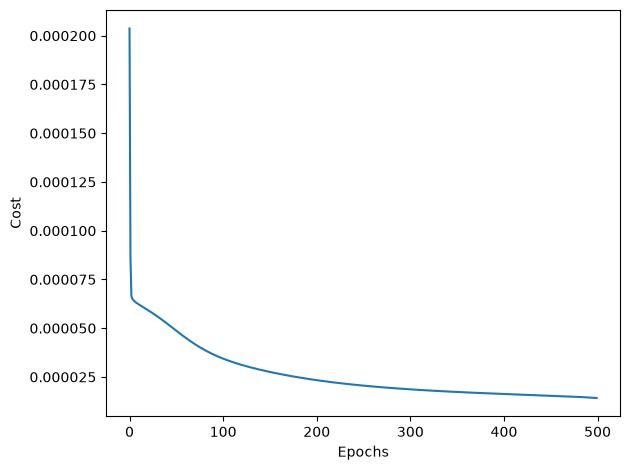

In [9]:
# create model
model = Model([Dense(64,32),
               Sigmoid(),
               Dense(32,10),
               Sigmoid()])

# set loss function
mse_loss = MSELoss()

#  training
epochs = 500
loss_curve = np.zeros(epochs)
print_every = 50

for epoch in range(epochs):
    # send model to perform a training step
    loss_curve[epoch]  = train_step(model, mse_loss, X_train, y_train_ohe, learning_rate = 1.0 )

    # print status
    if (epoch % print_every == 0) or (epoch+1  >= epochs):
        sys.stderr.write(f"\r{epoch + 1}/{epochs}, error={loss_curve[epoch]}")
        sys.stderr.flush()

#  testing 
y_hat = model(X_test.T,sparse=True)
acc = accuracy_score(y_test,y_hat)
print(model)
print(f'Accuracy on Test Data: {acc:.4f}')

# plotting
plt.plot(range(len(loss_curve)), loss_curve)
plt.ylabel('Cost')
plt.xlabel('Epochs')
plt.tight_layout()
plt.show()

### [Back to slides] 

## Adding complexity and functionality
So now we can calculate the gradient and update parameters, but we need to account for more optimization methods in this new space because the optmiization surface can be highly non-convex. We need to steer clear of local optima as best as possible. That means we need an optimizer class to do more interesting updates to the parameters. To start, let's create a generic stochastic gradient descent optimizer.

In [10]:
class Optimizer:
    def __init__(self, parameters): 
        self.parameters = parameters # passed by numpy reference
    def __str__(self):
        vals = sum([p.value.size for p in self.parameters])
        return f'Optimizer for {len(self.parameters)} layers with {vals} trainable parameters.'
    def step(self): pass
    def scheduler_step(self): pass

class SimpleSGD(Optimizer):
    def __init__(self, parameters, learning_rate):
        super().__init__(parameters)
        self.learning_rate = learning_rate
        
    def step(self):
        # create our own optimizer, SGD for now
        # this references the original model parameters
        for param in self.parameters:
            param.value -= param.grad * self.learning_rate

# new update step that uses optimizer and use mini-batching 
def train_step(model, optimizer, loss, x_train, y_train, batch_size=256):
    indices = np.arange(len(x_train))
    np.random.shuffle(indices)
    
    error = 0
    for i in range(0, len(indices), batch_size):
        batch_idx = indices[i : i + batch_size]
    
        x_batch = x_train[batch_idx]
        y_batch = y_train[batch_idx]
        
        model.zero_grad()
        output = model(x_batch.T)
        error += loss(y_batch.T, output)
        grad   = loss.backward()
        model.backward(grad)
    
        optimizer.step()
    
    error /= len(x_train)
    return error


500/500, error=1.773576116098999e-055

Accuracy on Test Data: 0.9861
Optimizer for 4 layers with 2410 trainable parameters.
Model: 4 operations.

Dense_0 	 | 2080 Trainable parameters
Sigmoid_1 	 | 0 Trainable parameters
Dense_2 	 | 330 Trainable parameters
Sigmoid_3 	 | 0 Trainable parameters



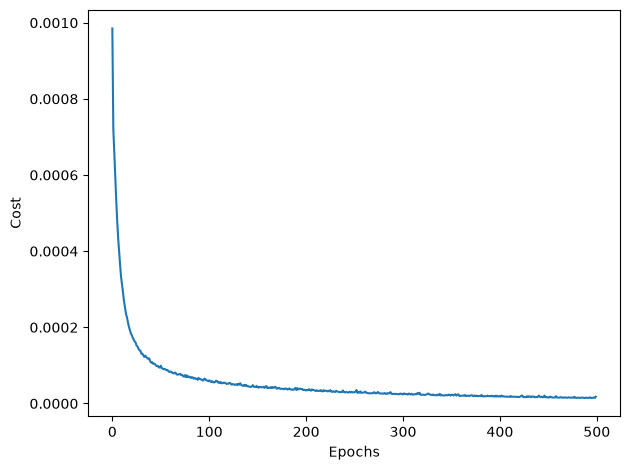

(None, None)

In [11]:
# create model
model = Model([Dense(64,32), Sigmoid(),
               Dense(32,10), Sigmoid()])
# set loss function
mse_loss = MSELoss()
opt = SimpleSGD(model.parameters, learning_rate=1.0)

#  training
epochs = 500
loss_curve = np.zeros(epochs)
print_every = 50

for epoch in range(epochs):
    # send model to perform a training step
    loss_curve[epoch]  = train_step(model, opt, mse_loss, X_train, y_train_ohe,  batch_size=128)

    # print status
    if (epoch % print_every == 0) or (epoch+1  >= epochs):
        sys.stderr.write(f"\r{epoch + 1}/{epochs}, error={loss_curve[epoch]}")
        sys.stderr.flush()

#  testing 
y_hat = model(X_test.T,sparse=True)
print(f'Accuracy on Test Data: {accuracy_score(y_test,y_hat):.4f}')

# summarizing 
print(opt)
print(model)
plt.plot(range(len(loss_curve)), loss_curve)
plt.ylabel('Cost'), plt.xlabel('Epochs')
plt.tight_layout(), plt.show()


_____
After the initial SGD setup, let's add: 
- some momentum to the calculation 
- $\eta$ learning rate decay
- perform mini-batching of the gradient updates 
- random reshuffling of the inputs

For cooling the learning rate, at epoch $k$:
$$ \mathbf{W}_{k+1} = \mathbf{W}_k - \frac{\eta}{1+\epsilon\cdot k} \cdot \rho_{k} $$

For momentum:
$$ \rho_{k} = \nabla J(\mathbf{W}_k) + \alpha\rho_{k-1} $$

For decaying the learning rate we will simply reduce it by a specific amount every so many epochs. 

1000/1000, error=1.1177186870814382e-05

Accuracy on Test Data: 0.9944


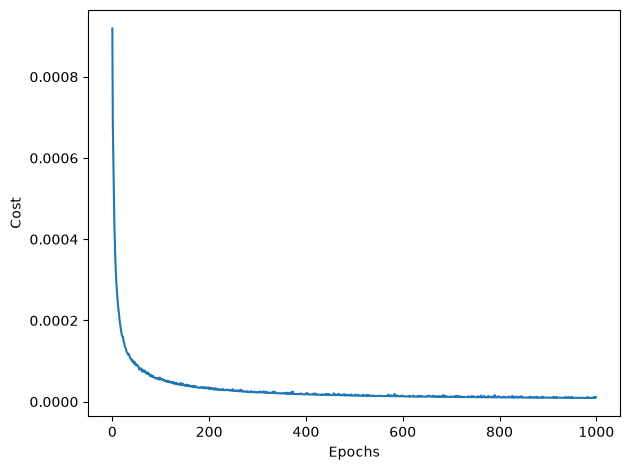

(None, None)

In [12]:

class SGD(Optimizer):
    def __init__(self, parameters, learning_rate, momentum, decay_rate=0.05, step_size=10, min_learning_rate = 1e-6):
        self.parameters = parameters # passed by numpy reference
        
        self.learning_rate = learning_rate
        self.learning_rate_min = min_learning_rate

        self.decay_rate = decay_rate 
        self.step_size = step_size
        
        self.momentum = momentum # alpha value
        
        # for momentum, we need to cache the previous gradient
        self._cache = [np.zeros_like(p.grad) for p in parameters] 

    def step(self):
        # create our own optimizer, using momentum
        for param, cache in zip(self.parameters, self._cache):
            cache[:] = param.grad + self.momentum * cache
            param.value -= self.learning_rate * cache
            
    def scheduler_step(self, epoch):
        # just update the scheduler here
        if epoch !=0 and (epoch % self.step_size) == 0:
            self.learning_rate *= self.decay_rate
            self.learning_rate = max(self.learning_rate, self.learning_rate_min)


# create model
model = Model([Dense(64,32), Sigmoid(),
               Dense(32,10), Sigmoid()])

# set loss function
mse_loss = MSELoss()
opt = SGD(model.parameters, learning_rate=1.0, momentum=0.1, decay_rate=0.9, step_size=100)

#  training
epochs = 1000
loss_curve = np.zeros(epochs)
print_every = 50

for epoch in range(epochs):
    # send model to perform a training step
    loss_curve[epoch]  = train_step(model, opt, mse_loss, X_train, y_train_ohe, batch_size=128)

    opt.scheduler_step(epoch)

    # print status
    if (epoch % print_every == 0) or (epoch+1  >= epochs):
        sys.stderr.write(f"\r{epoch + 1}/{epochs}, error={loss_curve[epoch]}")
        sys.stderr.flush()

#  testing 
y_hat = model(X_test.T,sparse=True)
print(f'Accuracy on Test Data: {accuracy_score(y_test,y_hat):.4f}')

# plotting
plt.plot(range(len(loss_curve)), loss_curve)
plt.ylabel('Cost'), plt.xlabel('Epochs')
plt.tight_layout(), plt.show()


In [13]:
opt.learning_rate

0.38742048900000015

## More layers
While the above implementation is good for a number of applications, we have yet to use more advanced optimization algorithms. Why is that? Shouldn't we remedy this situation?



1000/1000, error=3.5405219102196453e-06

Accuracy on Test Data: 0.9833


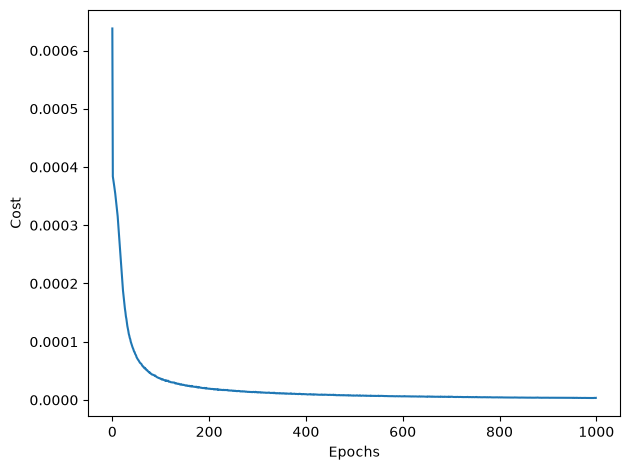

(None, None)

In [14]:
# create model
model = Model([Dense(64,50), Sigmoid(),
               Dense(50,32), Sigmoid(),
               Dense(32,10), Sigmoid()])

# set loss function
mse_loss = MSELoss()
opt = SGD(model.parameters, learning_rate=1.0, momentum=0.1, decay_rate=0.9, step_size=100)

#  training
epochs = 1000
loss_curve = np.zeros(epochs)
print_every = 50

for epoch in range(epochs):
    # send model to perform a training step
    loss_curve[epoch]  = train_step(model, opt, mse_loss, X_train, y_train_ohe)

    opt.scheduler_step(epoch)

    # print status
    if (epoch % print_every == 0) or (epoch+1  >= epochs):
        sys.stderr.write(f"\r{epoch + 1}/{epochs}, error={loss_curve[epoch]}")
        sys.stderr.flush()

#  testing 
y_hat = model(X_test.T,sparse=True)
print(f'Accuracy on Test Data: {accuracy_score(y_test,y_hat):.4f}')

# plotting
plt.plot(range(len(loss_curve)), loss_curve)
plt.ylabel('Cost'), plt.xlabel('Epochs')
plt.tight_layout(), plt.show()


  
___
# Using a bigger, more diverse dataset

Now let's load in a more diverse, harder to classify dataset: Fashion MNIST
https://www.kaggle.com/zalando-research/fashionmnist

**Labels**

Each training and test example is assigned to one of the following labels:

- T-shirt/top
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot 

In [15]:
# more data 
# Let's use Raschka's implementation for using the fashion mnist dataset:
# https://github.com/rasbt/python-machine-learning-book/blob/master/code/ch12/ch12.ipynb
import os
import struct
import numpy as np
 
def load_mnist(path, kind='fashion_train'):
    """Load Fashion MNIST data from `path`"""
    labels_path = os.path.join(path, '%s-labels-idx1-ubyte' % kind)
    images_path = os.path.join(path, '%s-images-idx3-ubyte' % kind)
        
    with open(labels_path, 'rb') as lbpath:
        magic, n = struct.unpack('>II', lbpath.read(8))
        labels = np.fromfile(lbpath, dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        magic, num, rows, cols = struct.unpack(">IIII", imgpath.read(16))
        images = np.fromfile(imgpath, dtype=np.uint8).reshape(len(labels), 784)

    labels_ohe = encoder.fit_transform(labels.reshape(-1, 1))
 
    return images, labels, labels_ohe

In [16]:
X_train, y_train, y_train_ohe = load_mnist('data/', kind='fashion_train')
print('Rows: %d, columns: %d' % (X_train.shape[0], X_train.shape[1]))

X_test, y_test, y_test_ohe = load_mnist('data/', kind='fashion_t10k')
print('Rows: %d, columns: %d' % (X_test.shape[0], X_test.shape[1]))

# don't forget to normalize
X_train = X_train/255.0 - 0.5
X_test = X_test/255.0 - 0.5

print(np.min(X_train),np.max(X_train))

Rows: 60000, columns: 784
Rows: 10000, columns: 784
-0.5 0.5


In [17]:
28*28

784

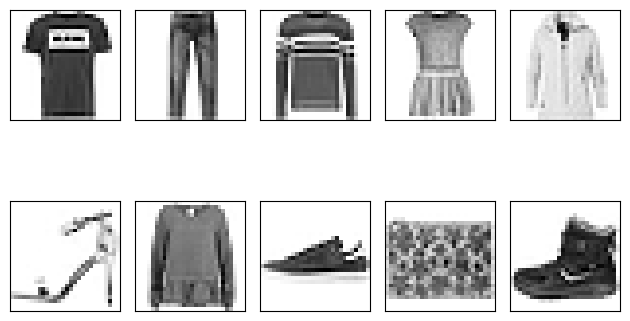

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True,)
ax = ax.flatten()
for i in range(10):
    img = X_train[y_train == i][0].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

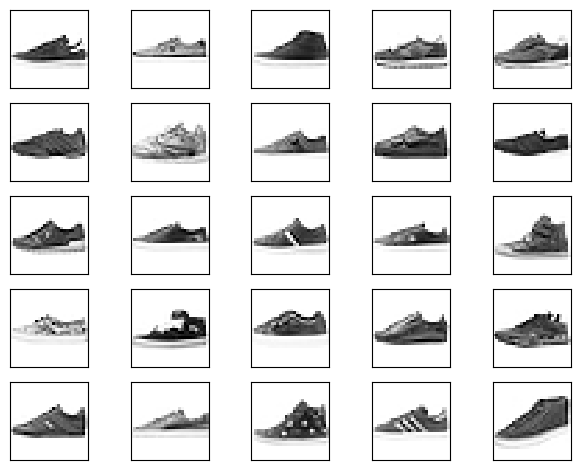

In [19]:
# 0,T-shirt/top
# 1,Trouser
# 2,Pullover
# 3 Dress
# 4 Coat
# 5 Sandal
# 6 Shirt
# 7 Sneaker
# 8 Bag
# 9 Ankle boot

fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True,)
ax = ax.flatten()
imgs_of_one_class = X_train[y_train == 7]
for i in range(25):
    img = imgs_of_one_class[i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

### Custom Neural Network Optimization for Fashion MNIST
This is a nice test to show that mini-batching has better conversion properties for some datasets.

15/15, error=0.00036988544694703453

Accuracy on Test Data: 0.6546


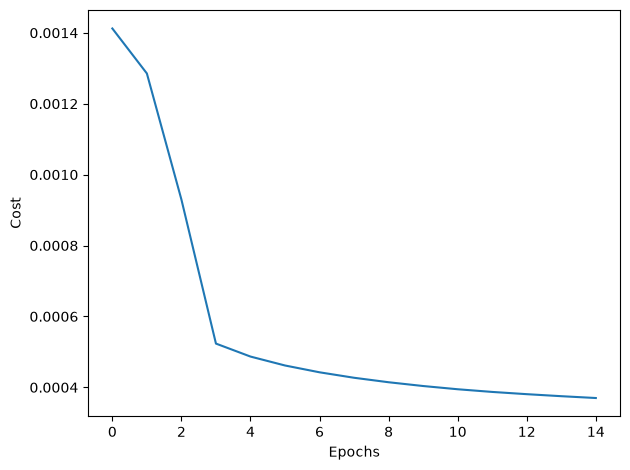

CPU times: user 4min 40s, sys: 21.6 s, total: 5min 1s
Wall time: 17.2 s


(None, None)

In [20]:
%%time

# create model
model = Model([Dense(784,256), Sigmoid(),
               Dense(256,128), Sigmoid(),
               Dense(128,10), Sigmoid()])

# set loss function
mse_loss = MSELoss()
opt = SGD(model.parameters, learning_rate=0.01, momentum=0.1, decay_rate=0.9, step_size=10)

#  training
epochs = 15
loss_curve = np.zeros(epochs)
print_every = 5

for epoch in range(epochs):
    # send model to perform a training step
    loss_curve[epoch]  = train_step(model, opt, mse_loss, X_train, y_train_ohe, batch_size=128)

    opt.scheduler_step(epoch)

    # print status
    if (epoch % print_every == 0) or (epoch+1  >= epochs):
        sys.stderr.write(f"\r{epoch + 1}/{epochs}, error={loss_curve[epoch]}")
        sys.stderr.flush()

#  testing 
y_hat = model(X_test.T,sparse=True)
print(f'Accuracy on Test Data: {accuracy_score(y_test,y_hat):.4f}')

# plotting
plt.plot(range(len(loss_curve)), loss_curve)
plt.ylabel('Cost'), plt.xlabel('Epochs')
plt.tight_layout(), plt.show()

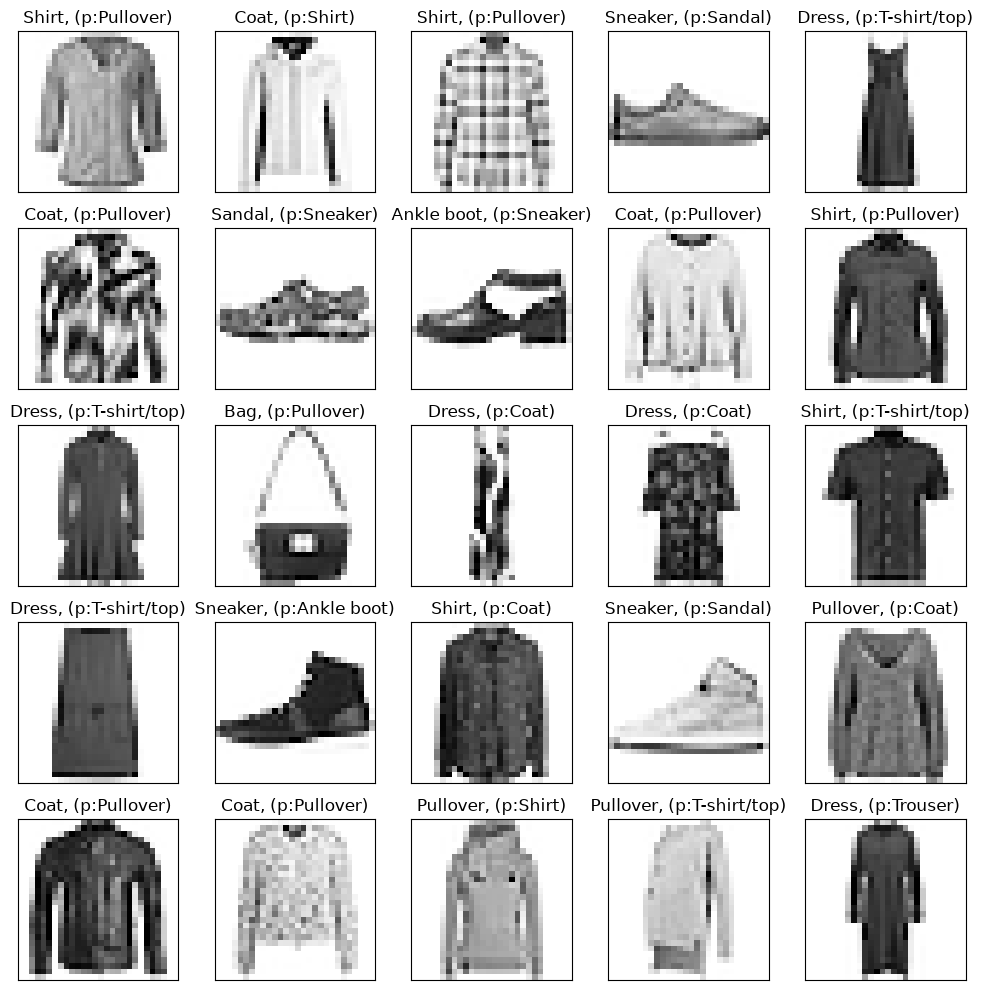

In [21]:
label_names=[
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot']

# get first 25 confusions
miscl_img = X_test[y_test != y_hat][:25]
correct_lab = y_test[y_test != y_hat][:25]
miscl_lab = y_hat[y_test != y_hat][:25]

fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True, figsize=(10,10))
ax = ax.flatten()
for i in range(25):
    img = miscl_img[i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')
    ax[i].set_title('%s, (p:%s)' % (label_names[correct_lab[i]],label_names[miscl_lab[i]]))

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

While these misclassifications are looking mostly okay, we can do better. Is 70% good for Fashion MNIST? Not really...  We can check out the leaderboard here: https://paperswithcode.com/sota/image-classification-on-fashion-mnist

We have some additional implementation details that are needed for practical implementation of neural networks, in order to get them training more efficiently and more meaningfully. These are visited in the next notebook, `07. Practical Neural Networks API`


## In this notebook you learned:
- an introduction to neural networks notation and programming
- using a two-layer perceptron architecture with sigmoid activations
- optimizing this network with mini-batch descent and Quasi-newton methods